In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(context="notebook", style="white", palette='deep')

In [4]:
df = pd.read_csv("../../datasets/08_manufacturing/manufacturing_kinetics_dataset.csv")

# **EDA**

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   batch_id                7500 non-null   int64  
 1   timestamp               7500 non-null   object 
 2   machine_id              7500 non-null   object 
 3   temperature_C           7500 non-null   float64
 4   pressure_bar            7500 non-null   float64
 5   raw_material_kg         7500 non-null   float64
 6   batch_size_kg           7500 non-null   float64
 7   reaction_rate_constant  7500 non-null   float64
 8   reaction_time_min       7500 non-null   float64
 9   machine_runtime_min     7500 non-null   float64
 10  downtime_min            7500 non-null   float64
 11  cycle_time_min          7500 non-null   float64
 12  conversion_percent      7500 non-null   float64
 13  production_kg           7500 non-null   float64
 14  defective_kg            7500 non-null   

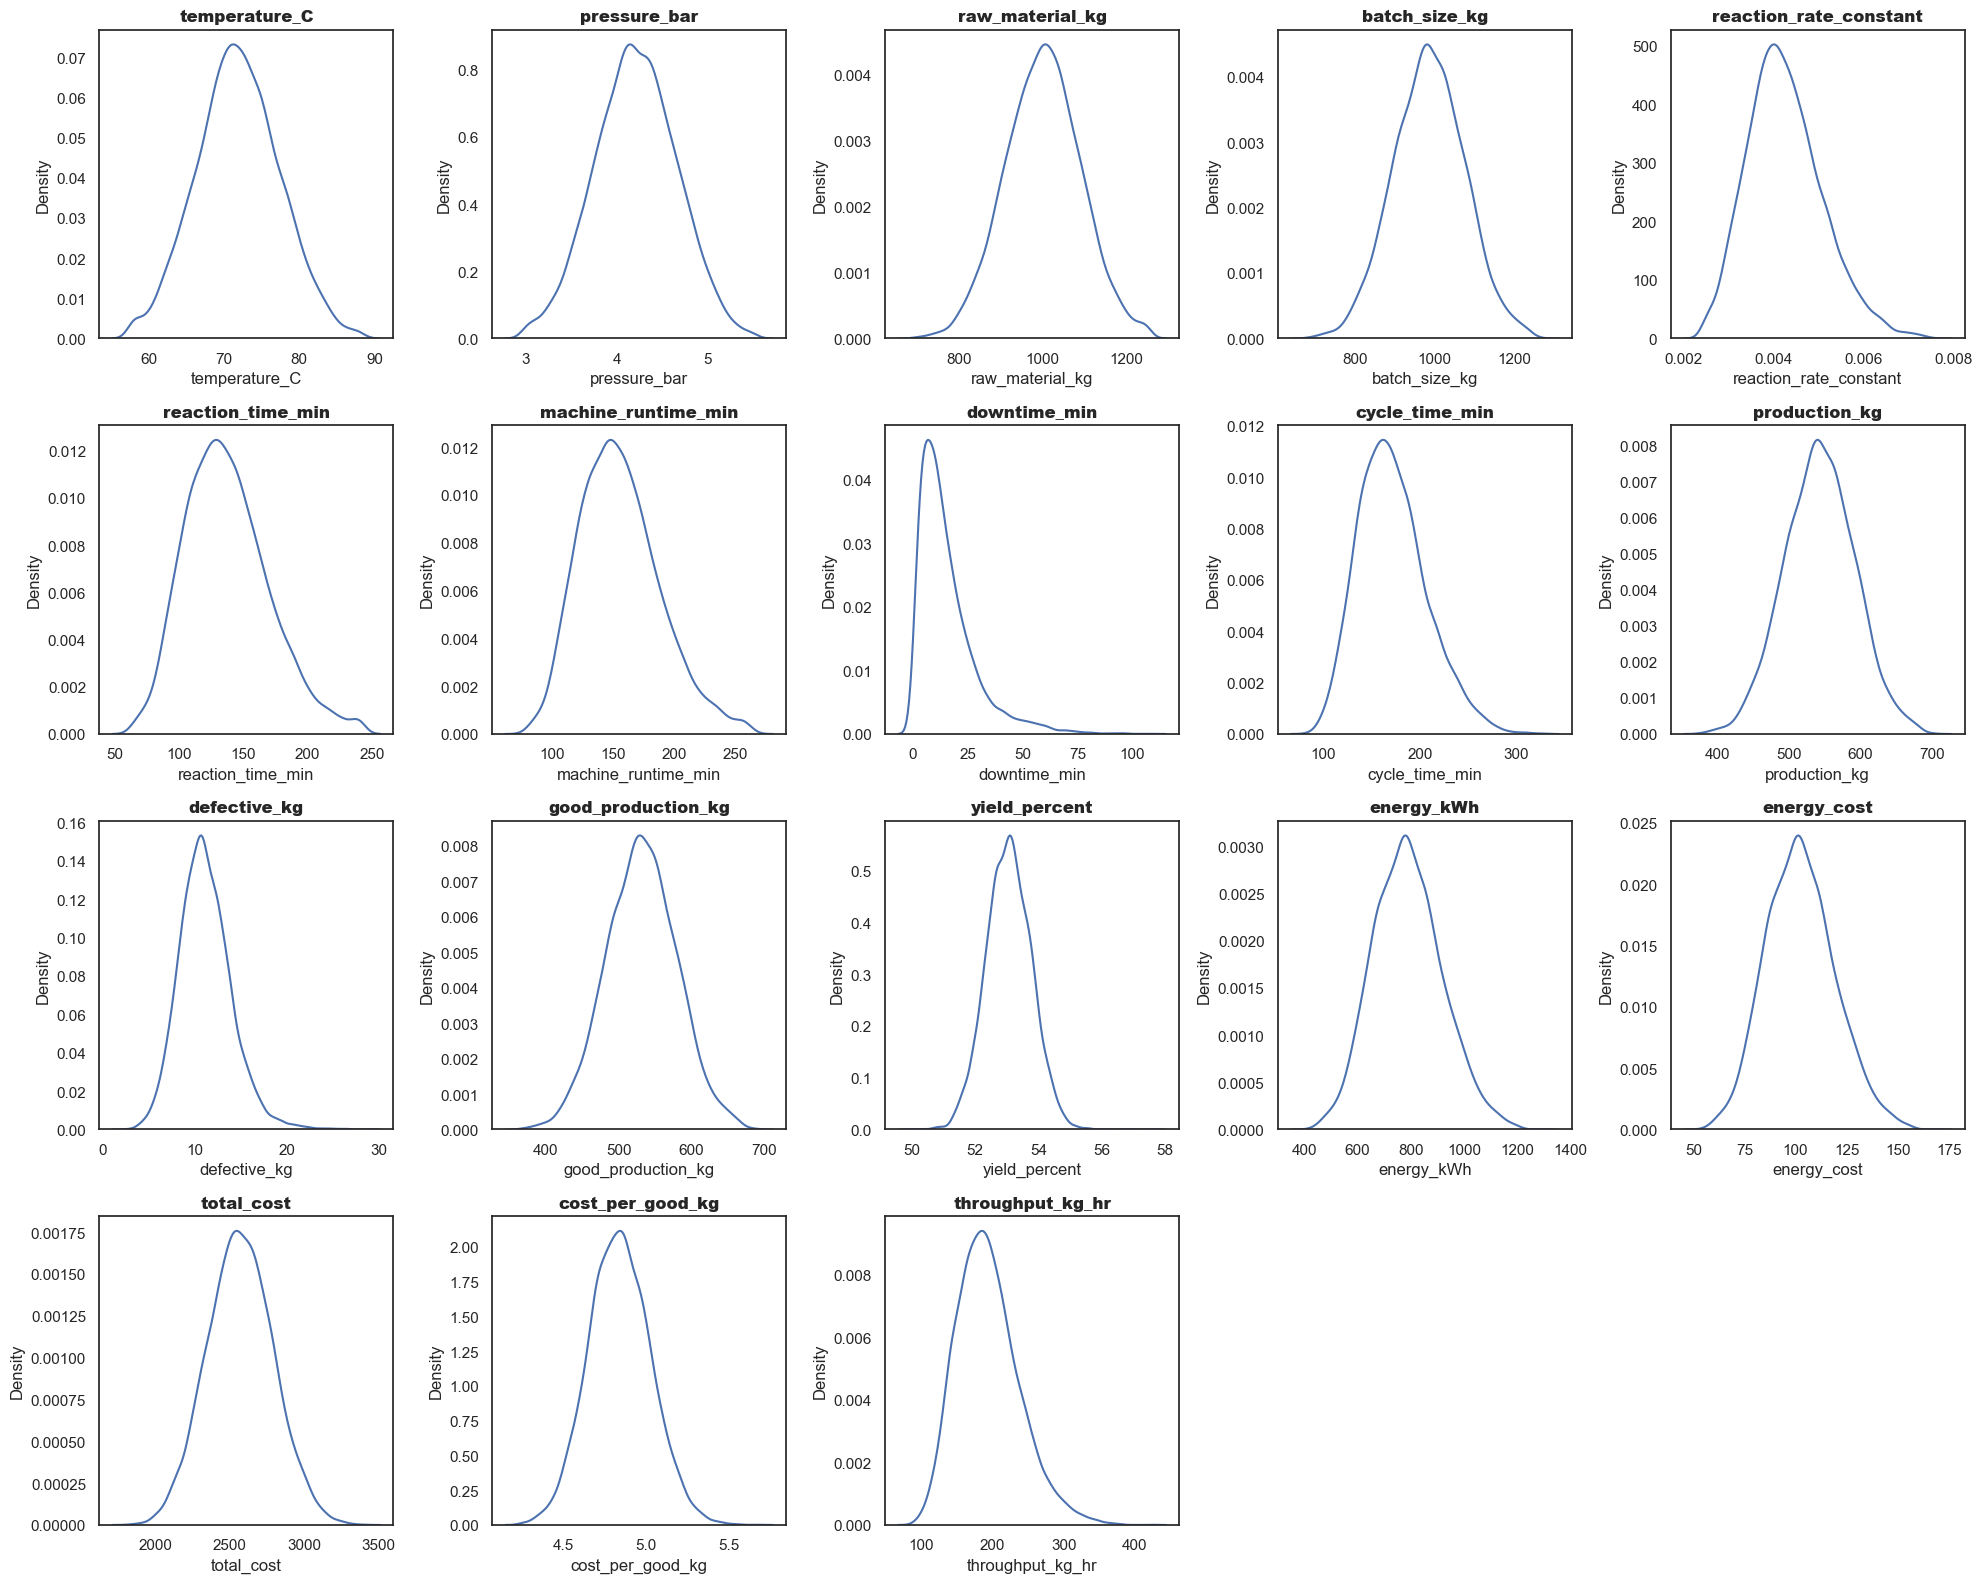

In [60]:
num_cols = df.drop(columns=["batch_id", "conversion_percent"]).select_dtypes(include="number").columns

ncols = 5
nrows = (len(num_cols) + ncols - 1) // ncols # (n + k - 1) // k

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(20, 4 * nrows)
)

axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, ax=ax)
    ax.set_title(col, fontweight=1000)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)


plt.tight_layout()
plt.show()

# **Formatting and cleaning the data**

In [61]:
machines = {}

for machine_id in df['machine_id'].unique():
    machines[machine_id] = df[df['machine_id'] == machine_id].copy().reset_index(drop=True)
    machines[machine_id]["ln_k"] = np.log(machines[machine_id]["reaction_rate_constant"])
    machines[machine_id]["temperature_K"] = machines[machine_id]["temperature_C"] + 273.15
    machines[machine_id]["1/T"] = 1/machines[machine_id]["temperature_K"]
    machines[machine_id].sort_values("timestamp")
    machines[machine_id]["month"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.month_name()
    machines[machine_id]["day"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.day
    machines[machine_id]["year"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.year
    machines[machine_id]["hour"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.hour
    machines[machine_id].drop(columns=["timestamp", "batch_id"])

In [62]:
df.groupby("machine_id")[["total_cost"]].aggregate(["mean", "std"])

total_cost            
                   mean         std
machine_id                         
M01         2571.756830  224.753648
M02         2569.050940  224.556183
M03         2565.423121  221.639676
M04         2572.166157  223.078437
M05         2577.012106  218.972995

[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]


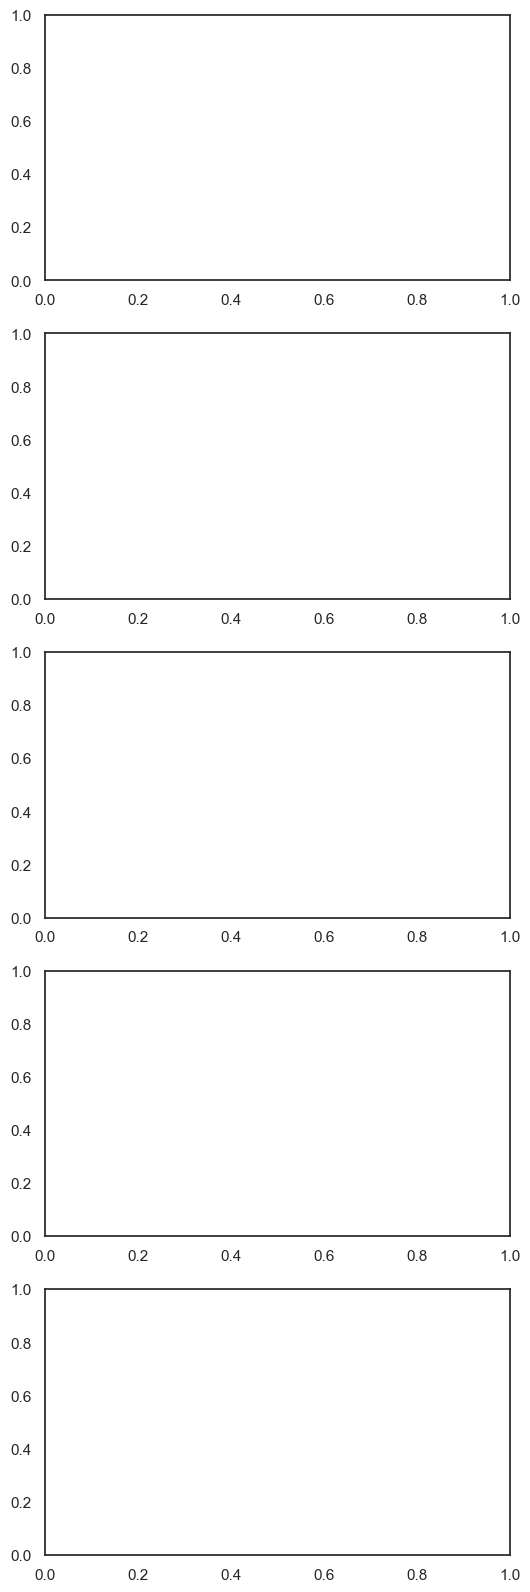

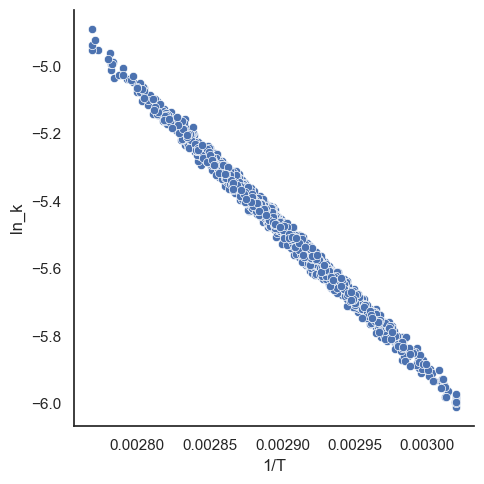

In [ ]:
nrows = len(machines)

fig, axes = plt.subplots(nrows=nrows, figsize=(6,4 * nrows))

sns.relplot(data=machines["M01"], x="1/T", y="ln_k", kind="scatter")
from scipy.stats import linregress
r = linregress(machines["M01"]["1/T"], machines["M01"]["ln_k"])